# Data Visualisation Report

## imports

In [26]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from wordcloud import WordCloud, STOPWORDS
color_list = ["#A5D7E8", "#19376D", "#0b2447"]

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_auc_score

from titanic import analysis, model, config


## data prep

In [27]:
config.TRAIN_PATH, config.TEST_PATH

from titanic.clean_data import (
    summarise_missing,
    summarise_frequent,
    summarise_uniques,
    clean_titanic_data
)

from titanic.load_data import load_train_data, load_test_data

train_raw = load_train_data(config.TRAIN_PATH)
test_raw  = load_test_data(config.TEST_PATH)

train_df = clean_titanic_data(train_raw)
test_df = clean_titanic_data(test_raw)

Loaded training data: 891 rows × 12 columns
Loaded test data: 418 rows × 11 columns


## Chart 1: Sex

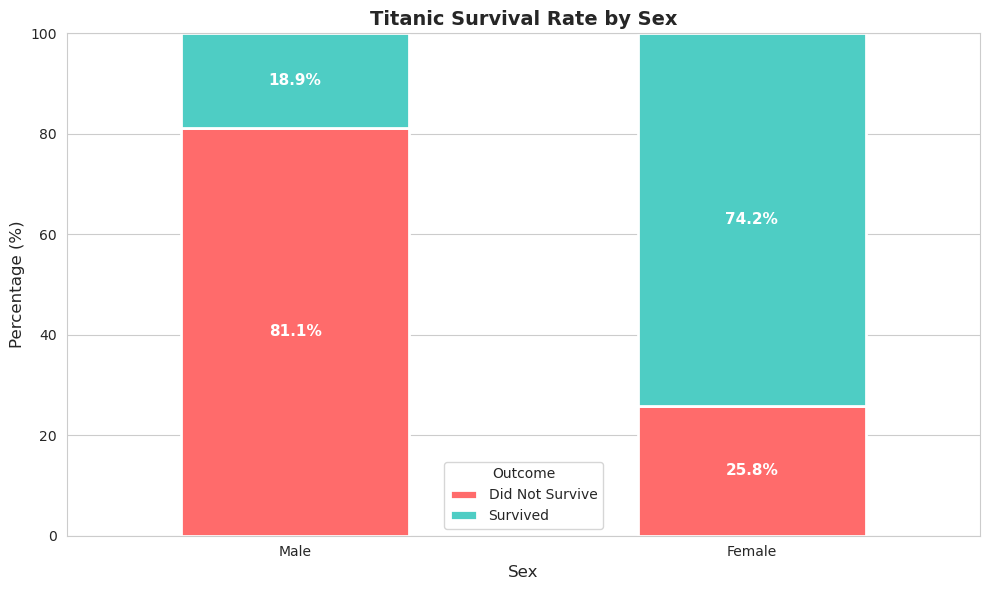

In [32]:
# Set style
sns.set_style("whitegrid")

# Calculate survival percentages by sex
survival_pct = train_df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
survival_pct = survival_pct.div(survival_pct.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

survival_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#FF6B6B', '#4ECDC4'], 
                  edgecolor='white', linewidth=2)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', 
                 fontsize=11, fontweight='bold', color='white')

ax.set_title('Titanic Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Sex', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['Male', 'Female'], rotation=0)
ax.legend(['Did Not Survive', 'Survived'], title='Outcome')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Chart 1 clearly shows that sex is a strong predictor for surviving. Sex is a clear candidate for feature selection.

## Chart 2: Ticket Class

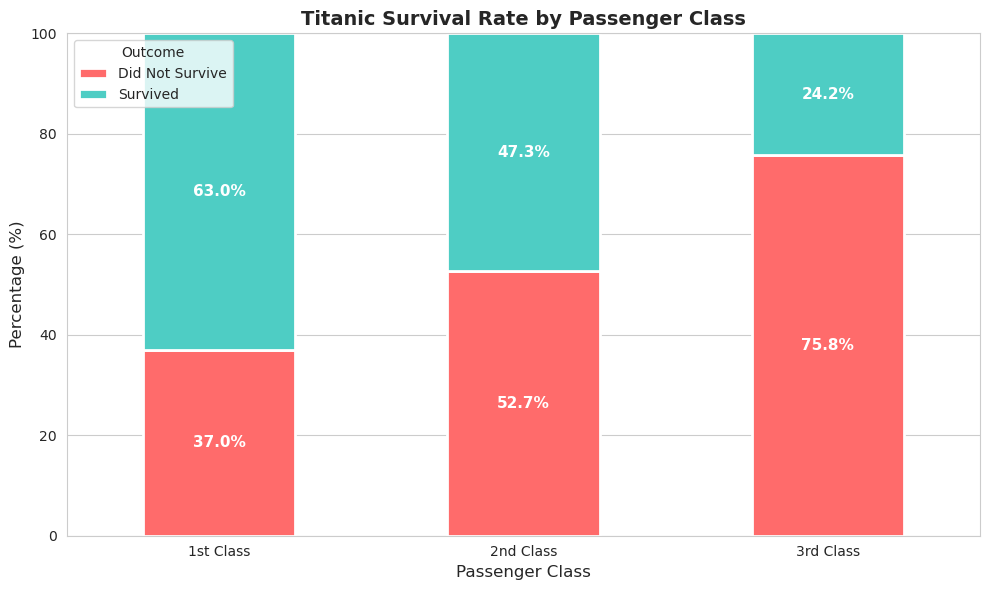

In [11]:
# Set style
sns.set_style("whitegrid")

# Calculate survival percentages by class
survival_pct = train_df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
survival_pct = survival_pct.div(survival_pct.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

survival_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#FF6B6B', '#4ECDC4'], 
                  edgecolor='white', linewidth=2)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', 
                 fontsize=11, fontweight='bold', color='white')

ax.set_title('Titanic Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax.legend(['Did Not Survive', 'Survived'], title='Outcome')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Chart 2 clearly shows that passenger class is a strong predictor for surviving. Passenger class is a clear candidate for feature selection.

## Chart 3: Ticket Class if Male

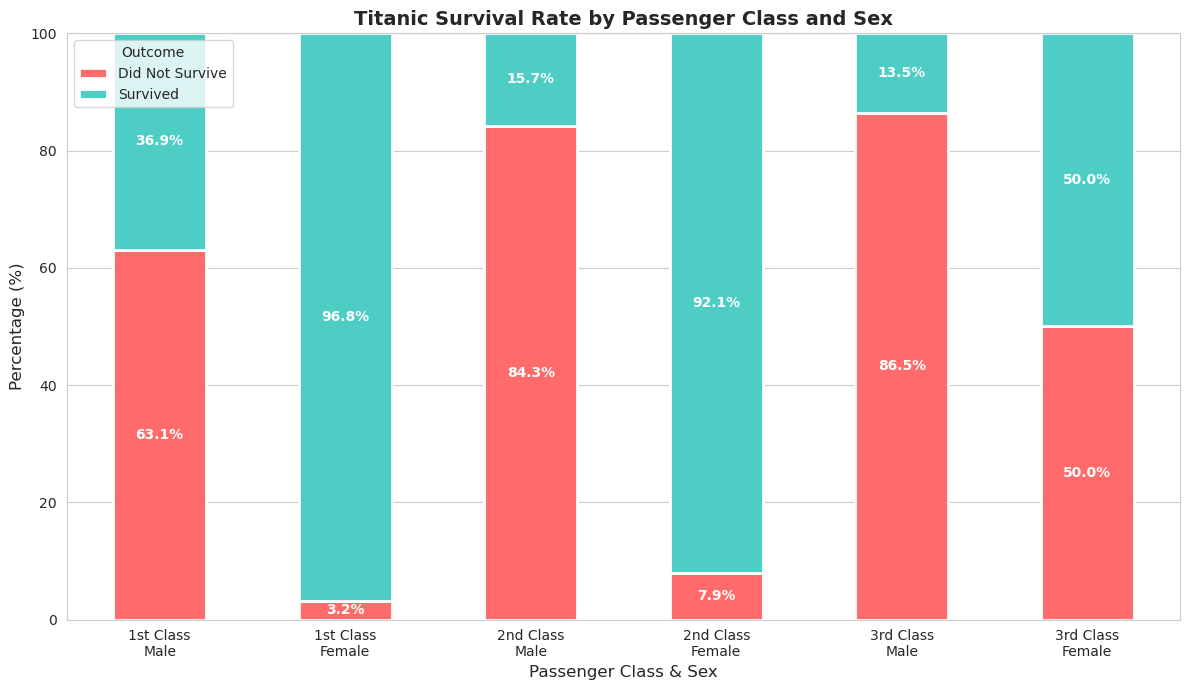

In [46]:
# Set style
sns.set_style("whitegrid")

# Calculate survival percentages by class and gender
# We group by Pclass and Sex, then unstack Survived
survival_pct = train_df.groupby(['Pclass', 'Sex', 'Survived']).size().unstack(fill_value=0)
survival_pct = survival_pct.div(survival_pct.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7)) # Made figure slightly wider

survival_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#FF6B6B', '#4ECDC4'], 
                  edgecolor='white', linewidth=2)

# Add percentage labels
for container in ax.containers:
    # Get labels, but only for values > 0 to avoid clutter
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', 
                 fontsize=10, fontweight='bold', color='white')

# --- New Labels for Combined Groups ---
# Create new, cleaner labels for the x-axis
new_labels = []
# Assuming 0=Male, 1=Female (based on your original 'male_df['Sex'] == 0')
for pclass, sex in survival_pct.index:
    class_str = f"{pclass}st"
    if pclass == 2: class_str = "2nd"
    if pclass == 3: class_str = "3rd"
    
    sex_str = "Male" if sex == 0 else "Female"
    
    new_labels.append(f"{class_str} Class\n{sex_str}")

ax.set_title('Titanic Survival Rate by Passenger Class and Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class & Sex', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(new_labels, rotation=0) # Apply new labels
ax.legend(['Did Not Survive', 'Survived'], title='Outcome', loc='upper left')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Interesting. Although passenger class shows a gradual increase in survivability from 3rd to 1st class, when breaking up by gender we see a different story.

## Chart 4: Child or Adult

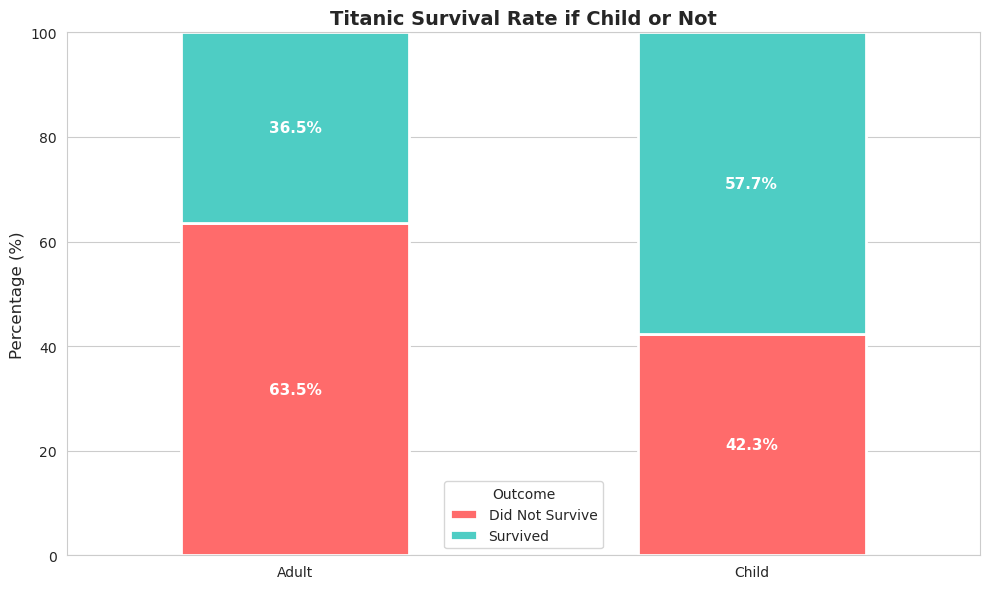

In [38]:
# Set style
sns.set_style("whitegrid")

# Add child variable
train_df["Child"] = (train_df["Age"] < 15).astype(int)

# Calculate survival percentages by class
survival_pct = train_df.groupby(['Child', 'Survived']).size().unstack(fill_value=0)
survival_pct = survival_pct.div(survival_pct.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

survival_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#FF6B6B', '#4ECDC4'], 
                  edgecolor='white', linewidth=2)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', 
                 fontsize=11, fontweight='bold', color='white')

ax.set_title('Titanic Survival Rate if Child or Not', fontsize=14, fontweight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['Adult', 'Child'], rotation=0)
ax.legend(['Did Not Survive', 'Survived'], title='Outcome')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Chart 4 clearly shows that being a child is a strong predictor for surviving. Child is a clear candidate for feature selection.

## Chart 5: Men with family

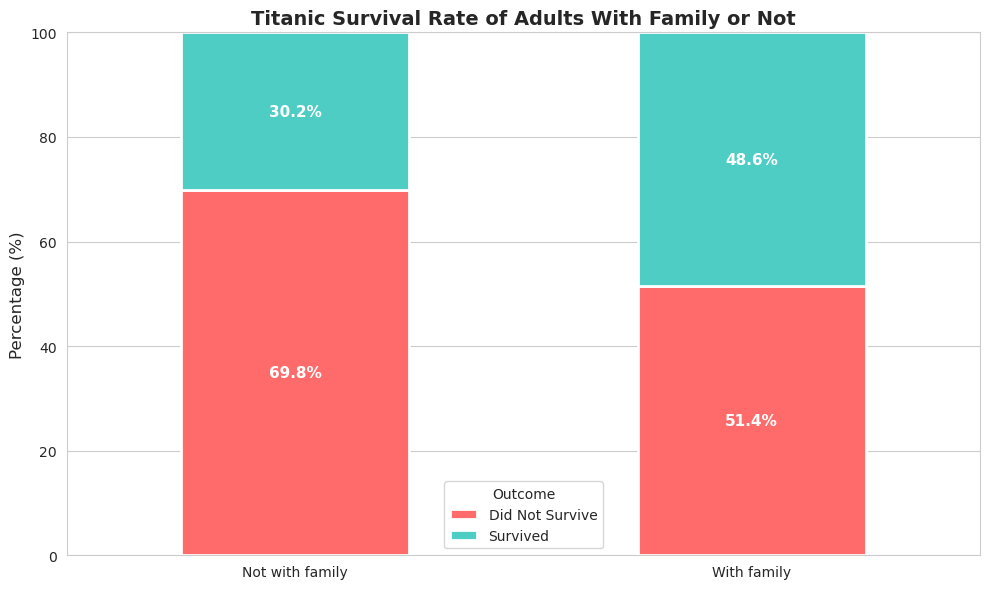

In [45]:
# Set style
sns.set_style("whitegrid")

# Add with variables
train_df["Child"] = (train_df["Age"] < 15).astype(int)
train_df['with family'] = np.where((train_df['Parch'] + train_df['SibSp']) > 0, 
                                 'with family', 
                                 'not with family')

adult_df = train_df[
    (train_df['Child'] == 0)
].copy()

# Calculate survival percentages by class
survival_pct = adult_df.groupby(['with family', 'Survived']).size().unstack(fill_value=0)
survival_pct = survival_pct.div(survival_pct.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

survival_pct.plot(kind='bar', stacked=True, ax=ax, 
                  color=['#FF6B6B', '#4ECDC4'], 
                  edgecolor='white', linewidth=2)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', 
                 fontsize=11, fontweight='bold', color='white')

ax.set_title('Titanic Survival Rate of Adults With Family or Not', fontsize=14, fontweight='bold')
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(['Not with family', 'With family'], rotation=0)
ax.legend(['Did Not Survive', 'Survived'], title='Outcome')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Chart 5 clearly shows that having a family is a strong predictor for surviving. Note, child was removed from this as we already know children are more likley to survive, and also are very likley to have family.

## Report: Justifying Feature Selection Through Visualization

This report highlights key visualizations from the provided data analysis notebook that support specific feature selection and engineering decisions for the Titanic survival model. The charts provide clear, empirical justification for including certain variables.

1. Core Categorical Predictors: 'Sex' and 'Pclass'

The most striking initial visualization is Chart 1, a count plot of survival by 'Sex'. This chart clearly demonstrates that 'Sex' is a powerful predictor. It shows a significantly higher survival count and proportion for females compared to males, immediately justifying its inclusion as a primary feature.

While 'Pclass' (Passenger Class) is also a good predictor individually (per Chart 2), its true value is revealed in Chart 3, a bar plot showing survival rates by both 'Sex' and 'Pclass'. This visualization is critical as it reveals a strong interaction effect. For instance, it shows that while females had a high survival rate overall, 3rd-class females had a much lower rate, almost comparable to 1st-class males. This visualization justifies not only including 'Sex' and 'Pclass' but also potentially considering their interaction, as their combined effect is more nuanced than their individual effects.

2. Justifying Feature Engineering: 'Child' and 'with family'

The notebook also justifies feature engineering—the creation of new features from existing data. The decision to convert the continuous 'Age' variable into a categorical 'Child' feature is supported by Chart 4. This count plot shows a distinct survival advantage for the 'Child' group, validating the hypothesis that age, particularly being a child, is a strong predictor.

Furthermore, the creation of a 'with family' feature is justified by Chart 5. This stacked bar chart, which focuses on adults, demonstrates a clear survival advantage for those traveling with family versus those traveling alone. This visualization confirms that the 'with family' variable captures a unique predictive signal, justifying its creation and inclusion in the model.